In [ ]:
!python -m pip install git+https://github.com/treforevans/uci_datasets.git

  Cloning https://github.com/treforevans/uci_datasets.git to /tmp/pip-req-build-xee5g1kj
  Running command git clone --filter=blob:none --quiet https://github.com/treforevans/uci_datasets.git /tmp/pip-req-build-xee5g1kj
  Resolved https://github.com/treforevans/uci_datasets.git to commit f0737523712fe66a1640e4b980b927e8490b58eb
  Preparing metadata (setup.py) ... done


Adaboost implementation from scratch

concrete dataset, N=1030, d=8
Data shape: (1030, 8) (1030,)
M=   5 | Val R^2 = 0.3837 | learners used=5
M=  10 | Val R^2 = 0.4405 | learners used=10
M=  20 | Val R^2 = 0.4417 | learners used=20
M=  40 | Val R^2 = 0.4421 | learners used=40
M=  60 | Val R^2 = 0.4531 | learners used=60
M=  80 | Val R^2 = 0.4526 | learners used=80
M= 100 | Val R^2 = 0.4870 | learners used=100
M= 150 | Val R^2 = 0.5274 | learners used=150
M= 200 | Val R^2 = 0.5250 | learners used=200
M= 500 | Val R^2 = 0.5573 | learners used=500
M=1000 | Val R^2 = 0.5734 | learners used=1000
M=5000 | Val R^2 = 0.6272 | learners used=5000
M=10000 | Val R^2 = 0.6266 | learners used=10000


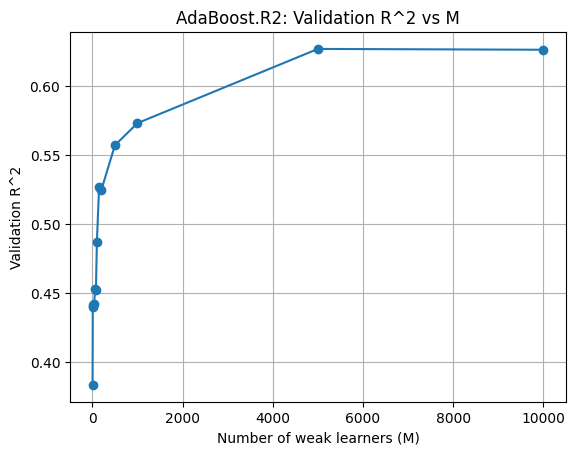


Best M on validation = 5000 (R^2 = 0.6272)
Test R^2 with best M=5000: 0.5833
Used 5000 learners; per-stage depths: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

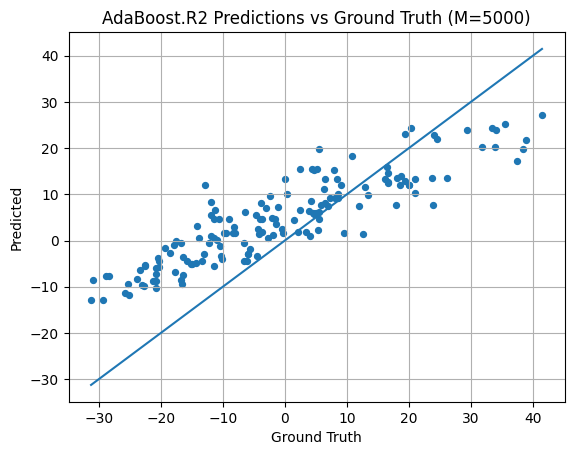

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import List, Optional, Sequence
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# in order to download dataset: python -m pip install git+https://github.com/treforevans/uci_datasets.git
from uci_datasets import Dataset


@dataclass
class StageModel:
    estimator: DecisionTreeRegressor
    alpha: float  # alpha_m = log(1/beta_m)
    depth: int    # depth used for this stage


class AdaBoostR2:
    def __init__(
        self,
        n_estimators: int = 50,
        base_max_depth: int = 1,
        max_depth_cap: int = 10,
        random_state: Optional[int] = None,
    ):
        self.n_estimators = int(n_estimators)
        self.base_max_depth = int(base_max_depth)
        self.max_depth_cap = int(max_depth_cap)
        self.random_state = random_state

        self.stages_: List[StageModel] = []
        self._fitted: bool = False

    # ---------- Core boosting ----------
    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n = X.shape[0]
        if n == 0:
            raise ValueError("Empty training set.")

        # Step 1: uniform weights
        w = np.ones(n, dtype=float) / n

        rng = np.random.RandomState(self.random_state)

        for m in range(self.n_estimators):
            # Try with increasing depth until e_m < 0.5 or we exhaust the cap
            chosen_estimator = None
            chosen_pred = None
            chosen_em = None
            chosen_depth = None

            for depth in range(self.base_max_depth, self.max_depth_cap + 1):
                est = DecisionTreeRegressor(max_depth=depth, random_state=rng.randint(0, 1_000_000))
                est.fit(X, y, sample_weight=w)
                y_hat = est.predict(X)

                # Step 2.2: normalized absolute loss L in [0,1]
                abs_err = np.abs(y - y_hat)
                max_abs = abs_err.max()

                # If perfect fit on the training data for this stage
                if max_abs <= 1e-12:
                    # Give a massive weight (alpha) and stop; further learners are unnecessary
                    beta = 1e-12
                    alpha = np.log(1.0 / beta)
                    self.stages_.append(StageModel(estimator=est, alpha=alpha, depth=depth))
                    self._fitted = True
                    return self

                L = abs_err / max_abs

                # Step 2.3: weighted error e_m
                em = float(np.sum(w * L) / (np.sum(w) + 1e-12))


                if em < 0.5:
                    chosen_estimator = est
                    chosen_pred = y_hat
                    chosen_em = em
                    chosen_depth = depth
                    break  # accept this depth

            # If we couldn't get e_m < 0.5 at any depth → stop boosting
            if chosen_estimator is None:
                break

            # Step 2.4: β_m
            beta = chosen_em / (1.0 - chosen_em + 1e-12)

            # Step 2.5: update weights with β_m^(1 - L_i)
            abs_err = np.abs(y - chosen_pred)
            max_abs = abs_err.max()
            L = abs_err / (max_abs + 1e-12)
            w = w * np.power(beta, (1.0 - L))

            # Step 2.6: normalize weights
            w_sum = w.sum()
            if w_sum <= 1e-20:  # numerical safety
                w = np.ones_like(w) / len(w)
            else:
                w = w / w_sum

            # Save stage with α_m
            alpha = np.log(1.0 / (beta + 1e-12))
            self.stages_.append(StageModel(estimator=chosen_estimator, alpha=alpha, depth=chosen_depth))

        self._fitted = True
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        if not self._fitted or len(self.stages_) == 0:
            raise RuntimeError("Model is not fitted yet.")
        X = np.asarray(X, dtype=float)

        alphas = np.array([s.alpha for s in self.stages_], dtype=float)  # shape (M,)
        preds = np.stack([s.estimator.predict(X) for s in self.stages_], axis=1)  # (N, M)

        denom = alphas.sum()
        if denom <= 1e-20:
            # fallback: simple mean
            return preds.mean(axis=1)
        return (preds * alphas.reshape(1, -1)).sum(axis=1) / denom

    # ---------- Convenience ----------
    @property
    def n_learners_(self) -> int:
        return len(self.stages_)

    def stage_depths_(self) -> List[int]:
        return [s.depth for s in self.stages_]

    def stage_alphas_(self) -> List[float]:
        return [s.alpha for s in self.stages_]


def load_uci_regression(dataset_name: str, split_num: int = 0):
    data = Dataset(dataset_name)
    x_train, y_train, x_test, y_test = data.get_split(split=split_num)
    # Concatenate to reshuffle and create our own train/val/test split below
    X = np.concatenate([x_train, x_test], axis=0)
    y = np.concatenate([y_train, y_test], axis=0)
    return X.astype(float), y.astype(float).ravel()


def sweep_M_and_plot(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    M_values: Sequence[int],
    base_max_depth: int = 1,
    max_depth_cap: int = 6,
    random_state: int = 0,
):
    r2_vals = []
    for M in M_values:
        model = AdaBoostR2(
            n_estimators=M,
            base_max_depth=base_max_depth,
            max_depth_cap=max_depth_cap,
            random_state=random_state,
        ).fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        r2 = r2_score(y_val, y_val_pred)
        r2_vals.append(r2)
        print(f"M={M:4d} | Val R^2 = {r2:.4f} | learners used={model.n_learners_}")

    # Plot R^2 vs M
    plt.figure()
    plt.plot(M_values, r2_vals, marker='o')
    plt.xlabel("Number of weak learners (M)")
    plt.ylabel("Validation R^2")
    plt.title("AdaBoost.R2: Validation R^2 vs M")
    plt.grid(True)
    plt.show()

    # Choose best M (highest R^2)
    best_idx = int(np.argmax(r2_vals))
    best_M = int(M_values[best_idx])
    best_r2 = float(r2_vals[best_idx])
    print(f"\nBest M on validation = {best_M} (R^2 = {best_r2:.4f})")
    return best_M, r2_vals


def train_with_best_M_and_test(
    X_train_full: np.ndarray,  # you can pass train+val here
    y_train_full: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    best_M: int,
    base_max_depth: int = 1,
    max_depth_cap: int = 6,
    random_state: int = 0,
):
    model = AdaBoostR2(
        n_estimators=best_M,
        base_max_depth=base_max_depth,
        max_depth_cap=max_depth_cap,
        random_state=random_state
    ).fit(X_train_full, y_train_full)

    y_test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_test_pred)
    print(f"Test R^2 with best M={best_M}: {test_r2:.4f}")
    print(f"Used {model.n_learners_} learners; per-stage depths: {model.stage_depths_()}")

    # Scatter: Predictions vs Ground Truth
    plt.figure()
    plt.scatter(y_test, y_test_pred, s=18)
    plt.xlabel("Ground Truth")
    plt.ylabel("Predicted")
    plt.title(f"AdaBoost.R2 Predictions vs Ground Truth (M={best_M})")
    # Reference y=x line
    lims = [
        min(np.min(y_test), np.min(y_test_pred)),
        max(np.max(y_test), np.max(y_test_pred)),
    ]
    plt.plot(lims, lims)
    plt.grid(True)
    plt.show()

    return model, test_r2


if __name__ == "__main__":
    # --- Dataset selection ---
    dataset_name = "concrete"   # change to any valid UCI dataset name available in the package
    X_all, y_all = load_uci_regression(dataset_name, split_num=0)
    print("Data shape:", X_all.shape, y_all.shape)

    # --- Train/Val/Test split ---
    # First hold out a test set
    X_tmp, X_test, y_tmp, y_test = train_test_split(X_all, y_all, test_size=0.15, random_state=1)
    # Then split the remainder into train and validation
    X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.15, random_state=1)

    # --- (i) Sweep M and plot validation R^2 ---
    # Choose a sensible sweep range (feel free to adjust or densify):
    M_values = [5, 10, 20, 40, 60, 80, 100, 150, 200, 500, 1000, 5000, 10000]
    best_M, r2_vals = sweep_M_and_plot(
        X_train, y_train, X_val, y_val,
        M_values=M_values,
        base_max_depth=1,     # start with stumps
        max_depth_cap=6,      # allow deeper trees only if needed (e_m >= 0.5)
        random_state=0
    )

    # --- (ii) Retrain with best M and evaluate on the test set ---
    # Common practice: retrain on TRAIN+VAL for the final model
    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val], axis=0)

    final_model, test_r2 = train_with_best_M_and_test(
        X_train_full, y_train_full, X_test, y_test,
        best_M=best_M,
        base_max_depth=1,
        max_depth_cap=6,
        random_state=0
    )



Adaboost implementation from sklearn

concrete dataset, N=1030, d=8
Data shape: (1030, 8) (1030,)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best params from CV: {'learning_rate': 1.0, 'n_estimators': 200}
Best CV R^2: 0.8137

[Test] R^2 with best (M=200, lr=1.0): 0.8179


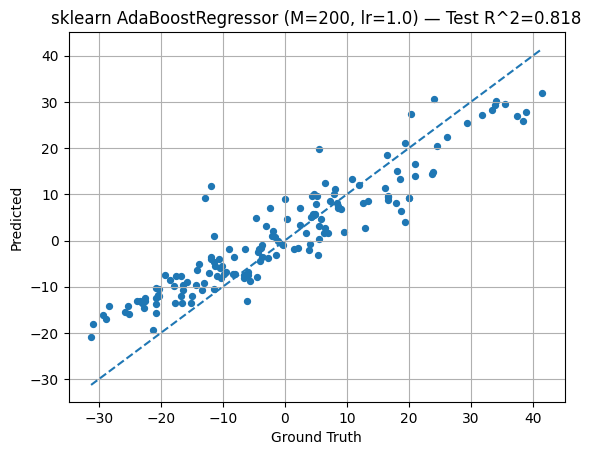

In [ ]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
import sklearn
from packaging import version

# in order to download dataset: python -m pip install git+https://github.com/treforevans/uci_datasets.git
from uci_datasets import Dataset


def load_uci_regression(dataset_name: str, split_num: int = 0):
    data = Dataset(dataset_name)
    x_train, y_train, x_test, y_test = data.get_split(split=split_num)
    X = np.concatenate([x_train, x_test], axis=0)
    y = np.concatenate([y_train, y_test], axis=0)
    return X.astype(float), y.astype(float).ravel()


def make_adaboost(base_tree: DecisionTreeRegressor, n_estimators: int, learning_rate: float, loss: str = "square", random_state: int = 0):
    """Create AdaBoostRegressor with version-safe base estimator arg."""
    kwargs = dict(n_estimators=n_estimators, learning_rate=learning_rate, loss=loss, random_state=random_state)
    if version.parse(sklearn.__version__) >= version.parse("1.2"):
        return AdaBoostRegressor(estimator=base_tree, **kwargs)
    else:
        return AdaBoostRegressor(base_estimator=base_tree, **kwargs)


if __name__ == "__main__":
    # --- Config ---
    dataset_name = "concrete"       # change if you want another UCI regression dataset
    random_state = 1

    # --- Data ---
    X_all, y_all = load_uci_regression(dataset_name, split_num=0)
    print("Data shape:", X_all.shape, y_all.shape)

    # Hold out TEST
    X_tmp, X_test, y_tmp, y_test = train_test_split(X_all, y_all, test_size=0.15, random_state=random_state)
    # Split remainder into TRAIN and VAL (we’ll combine these for CV)
    X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.15, random_state=random_state)

    # Use TRAIN+VAL for cross-validation (TEST remains untouched)
    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val], axis=0)

    # Base learner: same stump as before
    base_tree = DecisionTreeRegressor(max_depth=3, random_state=0)

    # --- Hyperparameter grid (M and learning_rate) ---
    M_grid = [10, 20, 40, 60, 80, 100, 150, 200]
    lr_grid = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]

    # Build a "template" estimator for GridSearchCV; params will be overridden
    ab_template = make_adaboost(base_tree, n_estimators=50, learning_rate=1.0, loss="square", random_state=0)

    # GridSearchCV on TRAIN+VAL with KFold CV and R^2 scoring
    param_grid = {
        "n_estimators": M_grid,
        "learning_rate": lr_grid,
    }
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        estimator=ab_template,
        param_grid=param_grid,
        scoring="r2",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
    )
    grid.fit(X_train_full, y_train_full)

    print("\nBest params from CV:", grid.best_params_)
    print("Best CV R^2:", f"{grid.best_score_:.4f}")

    best_M = grid.best_params_["n_estimators"]
    best_lr = grid.best_params_["learning_rate"]

    # --- Retrain final model on TRAIN+VAL with best params ---
    final_model = make_adaboost(base_tree, n_estimators=best_M, learning_rate=best_lr, loss="square", random_state=0)
    final_model.fit(X_train_full, y_train_full)

    # --- Evaluate on TEST ---
    y_pred_test = final_model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred_test)
    print(f"\n[Test] R^2 with best (M={best_M}, lr={best_lr}): {test_r2:.4f}")

    # --- Scatter: Predictions vs Ground Truth ---
    plt.figure()
    plt.scatter(y_test, y_pred_test, s=18)
    plt.xlabel("Ground Truth")
    plt.ylabel("Predicted")
    plt.title(f"sklearn AdaBoostRegressor (M={best_M}, lr={best_lr}) — Test R^2={test_r2:.3f}")
    lo = min(np.min(y_test), np.min(y_pred_test))
    hi = max(np.max(y_test), np.max(y_pred_test))
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.grid(True)
    plt.show()
